# Phase 3: Data Preparation

**CRISP-DM Phase Description:**  
This phase covers all activities to construct the final dataset from the initial raw data. Data preparation tasks are likely to be performed multiple times, and not in any prescribed order. This is typically the longest and most time-consuming phase of the CRISP-DM lifecycle.

---

In [143]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
%matplotlib inline

In [144]:
# Load the dataset from Phase 2 (update the path as needed)
DATA_PATH = "../data/raw/applications.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded dataset: 182080 rows x 16 columns


,id,teacher_id,teacher_prefix,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_essay_1,project_essay_2,project_essay_3,project_essay_4,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved
0,p036502,484aaf11257089a66cfedc9461c6bd0a,Ms.,NV,2016-11-18 14:45:59,Grades PreK-2,Literacy & Language,Literacy,Super Sight Word Centers,Most of my kindergarten students come from low...,I currently have a differentiated sight word c...,NaN,NaN,My students need 6 Ipod Nano's to create and d...,26,1
1,p039565,df72a3ba8089423fa8a94be88060f6ed,Mrs.,GA,2017-04-26 15:57:28,Grades 3-5,"Music & The Arts, Health & Sports","Performing Arts, Team Sports",Keep Calm and Dance On,Our elementary school is a culturally rich sch...,We strive to provide our diverse population of...,NaN,NaN,My students need matching shirts to wear for d...,1,0
2,p233823,a9b876a9252e08a55e3d894150f75ba3,Ms.,UT,2017-01-01 22:57:44,Grades 3-5,"Math & Science, Literacy & Language","Applied Sciences, Literature & Writing",Lets 3Doodle to Learn,Hello;\r\nMy name is Mrs. Brotherton. I teach ...,We are looking to add some 3Doodler to our cla...,NaN,NaN,My students need the 3doodler. We are an SEM s...,5,1
3,p185307,525fdbb6ec7f538a48beebaa0a51b24f,Mr.,NC,2016-08-12 15:42:11,Grades 3-5,Health & Sports,Health & Wellness,"\""Kid Inspired\"" Equipment to Increase Activit...",My students are the greatest students but are ...,"The student's project which is totally \""kid-i...",NaN,NaN,My students need balls and other activity equi...,16,0
4,p013780,a63b5547a7239eae4c1872670848e61a,Mr.,CA,2016-08-06 09:09:11,Grades 6-8,Health & Sports,Health & Wellness,We need clean water for our culinary arts class!,My students are athletes and students who are ...,For some reason in our kitchen the water comes...,NaN,NaN,My students need a water filtration system for...,42,1


________________________________________________________________________________________________________________________________________________________________________________________________

---
### Task 1: Select Data

Decide on the data to be used for analysis. Consider which columns (features) and rows (records) to include or exclude based on:

- **Relevance:** Does this feature contribute to the data mining goal?
- **Data Quality:** Is the quality of this feature sufficient (e.g., too many missing values)?
- **Technical Constraints:** Are there limitations on data volume or specific feature types?

**Output:** A rationale for inclusion/exclusion of data, and the resulting subset.

**Instructions:** Select the columns and rows relevant to your analysis goal. Document your reasoning.

#### Objective
Select the most relevant features (columns) and records (rows) for the modelling process.

#### Approach
The dataset contains both useful and non-useful attributes. 
Some columns such as ID's or any unique identifiers do not take part in predicting the target variable and may cause data noise.

#### Actions Taken
- Removed identifier columns such as 'id' and 'teacher_id' as they do not provide predictive value.
- Kept the target variable 'project_is_approved' for modeling.
- Retained columns related to teacher experience, project details, and other meaningful attributes.

#### Reason for Selecting Data
Removing irrelevant features improves model performance by:
- Reducing noise in the dataset.
- Preventing overfitting.
- Improving computationa; efficiency.

#### Output
A filtered datset ('df_selected') containing only relevant features for further processing.

In [145]:
# Select the relevant columns and rows for your analysis.

# Copy the dataset
df_selected = df.copy()

# Exlude irrelevant columns
columns_exclude = {'id', 'teacher_id', 'project_essay_3', 'project_essay_4'}
df_selected = df_selected.drop(columns=columns_exclude)

# Check result
print("Shape after selection: ", df_selected.shape)
df_selected.head()

Shape after selection:  (182080, 12)


,teacher_prefix,school_state,project_submitted_datetime,project_grade_category,project_subject_categories,project_subject_subcategories,project_title,project_essay_1,project_essay_2,project_resource_summary,teacher_number_of_previously_posted_projects,project_is_approved
0,Ms.,NV,2016-11-18 14:45:59,Grades PreK-2,Literacy & Language,Literacy,Super Sight Word Centers,Most of my kindergarten students come from low...,I currently have a differentiated sight word c...,My students need 6 Ipod Nano's to create and d...,26,1
1,Mrs.,GA,2017-04-26 15:57:28,Grades 3-5,"Music & The Arts, Health & Sports","Performing Arts, Team Sports",Keep Calm and Dance On,Our elementary school is a culturally rich sch...,We strive to provide our diverse population of...,My students need matching shirts to wear for d...,1,0
2,Ms.,UT,2017-01-01 22:57:44,Grades 3-5,"Math & Science, Literacy & Language","Applied Sciences, Literature & Writing",Lets 3Doodle to Learn,Hello;\r\nMy name is Mrs. Brotherton. I teach ...,We are looking to add some 3Doodler to our cla...,My students need the 3doodler. We are an SEM s...,5,1
3,Mr.,NC,2016-08-12 15:42:11,Grades 3-5,Health & Sports,Health & Wellness,"\""Kid Inspired\"" Equipment to Increase Activit...",My students are the greatest students but are ...,"The student's project which is totally \""kid-i...",My students need balls and other activity equi...,16,0
4,Mr.,CA,2016-08-06 09:09:11,Grades 6-8,Health & Sports,Health & Wellness,We need clean water for our culinary arts class!,My students are athletes and students who are ...,For some reason in our kitchen the water comes...,My students need a water filtration system for...,42,1


---
### Task 2: Clean Data

Raise data quality to the level required by the selected analysis techniques. Cleaning activities include:

- **Handle Missing Values:** Impute missing values (mean, median, mode, forward/backward fill) or remove rows/columns with excessive missing data.
- **Correct Errors:** Fix inaccurate or corrupted data entries.
- **Remove Duplicates:** Eliminate exact or near-duplicate records.
- **Handle Outliers:** Decide how to treat extreme values (keep, cap, transform, or remove).

**Instructions:** Apply appropriate cleaning techniques to address the data quality issues identified in Phase 2, Task 4.

#### Objective
Improve data quality by handling missing values, duplicate records, and outliers.

#### Approach
Raw datasets often contain inconsistencies that can negatively impact model performance.
This step ensures the dataset is accurate, complete, and reliable.

#### Actions Taken
##### 1. Handling Missing Values
- Numerical columns were filled using the median value.
- Categorical columns were filled using the most frequent value (mode).

##### 2. Removing Dupllicates
- Duplicate rows were identified and removed to avoid bias in the model.

##### 3. Handling Outliers
- Outliers were detected and capped using the Interquartile Range (IQR) method.

#### Reasoning
- Missing values can distort analysis and model training.
- Duplicate records can bias results.
- Outliers can negatively affect model accuracy.

#### Output
A cleaned dataset ('df_clean') ready for feature engineering and modelling.


In [146]:
# Handle missing values.
# Copy the dataset
df_clean = df_selected.copy()

# Remove the 4 rows with missing teacher_prefix
df_clean = df_clean[df_clean['teacher_prefix'].notnull()]

# Strategy 3: Drop rows/columns with too many missing values
print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


In [147]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 182076 entries, 0 to 182079
Data columns (total 12 columns):
 #   Column                                        Non-Null Count   Dtype
---  ------                                        --------------   -----
 0   teacher_prefix                                182076 non-null  str  
 1   school_state                                  182076 non-null  str  
 2   project_submitted_datetime                    182076 non-null  str  
 3   project_grade_category                        182076 non-null  str  
 4   project_subject_categories                    182076 non-null  str  
 5   project_subject_subcategories                 182076 non-null  str  
 6   project_title                                 182076 non-null  str  
 7   project_essay_1                               182076 non-null  str  
 8   project_essay_2                               182076 non-null  str  
 9   project_resource_summary                      182076 non-null  str  
 10  teacher_numb

In [148]:
# Handle outliers.
# Choose a strategy: capping (winsorizing), removing, or transforming.

# Cap outliers using the IQR method
upper = df_clean['teacher_number_of_previously_posted_projects'].quantile(0.99)
df_clean['teacher_number_of_previously_posted_projects'] = \
    df_clean['teacher_number_of_previously_posted_projects'].clip(upper = upper)
(df_clean['teacher_number_of_previously_posted_projects'] > upper).sum()

np.int64(0)

In [149]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 182076 entries, 0 to 182079
Data columns (total 12 columns):
 #   Column                                        Non-Null Count   Dtype
---  ------                                        --------------   -----
 0   teacher_prefix                                182076 non-null  str  
 1   school_state                                  182076 non-null  str  
 2   project_submitted_datetime                    182076 non-null  str  
 3   project_grade_category                        182076 non-null  str  
 4   project_subject_categories                    182076 non-null  str  
 5   project_subject_subcategories                 182076 non-null  str  
 6   project_title                                 182076 non-null  str  
 7   project_essay_1                               182076 non-null  str  
 8   project_essay_2                               182076 non-null  str  
 9   project_resource_summary                      182076 non-null  str  
 10  teacher_numb

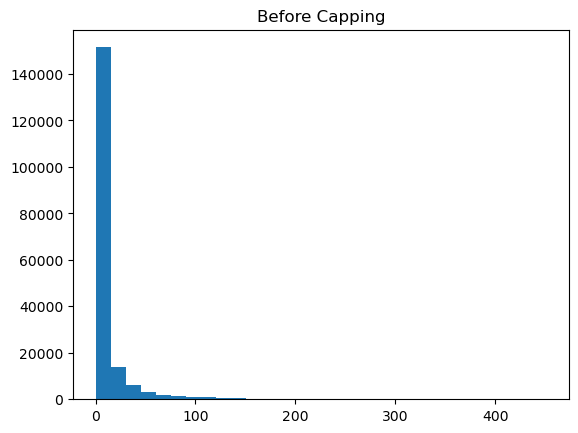

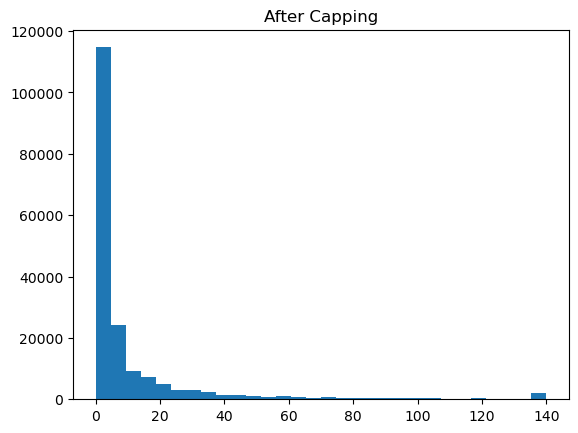

In [150]:
plt.hist(df['teacher_number_of_previously_posted_projects'], bins=30 )
plt.title("Before Capping")
plt.show()

plt.hist(df_clean['teacher_number_of_previously_posted_projects'], bins=30)
plt.title("After Capping")
plt.show()

---
### Task 3: Construct Data (Feature Engineering)

This task involves creating new attributes (features) derived from existing ones that may be more useful for modelling. Common techniques include:

- **Derived Attributes:** Create new features from existing ones (e.g., extracting `year`, `month`, `day` from a datetime column; computing `total_spend = price * quantity`).
- **Binning / Discretisation:** Convert continuous variables into categorical bins (e.g., age groups).
- **Encoding Categorical Variables:** Convert categorical features into numerical representations (e.g., one-hot encoding, label encoding).
- **Scaling / Normalisation:** Scale numerical features to a common range (e.g., Min-Max scaling, Standardisation).

**Instructions:** Create new features or transform existing ones to improve model performance.

#### Objective
Create new features and transform existing ones to improve model performance.

#### Approach
Feature engineering enhances the dataset by extracting useful information from existing features and converting data into a format suitable for training unsupervised models.

#### Actions Taken
##### 1. Derived Features
- Extracted data-related features (year, month, day of week) from 'project_submitted-datetime'.
- These features help identify temporal patterns in approvals..

##### 2. Encoding Categorical Variables
- Converted categorical variables into numerical format using many types of encoding.
- This allows machine learning models to process non-numeric data.

##### 3. Scaling Numerical Features
- Applied standard scaling to numerical columns to normalise their values.
- This ensures all features contribute equally during model training.

#### Reasoning
- Derived features capture hidden patterns in the data.
- Encoding is required because most models cannot handle text directly.
- Scalling improves model stability and performance.

#### Output
A transformed dataset ('df_features') ready for modelling.

### Binary Encoding for 2 columns

In [151]:
import category_encoders as ce

binary_encoder = ce.BinaryEncoder(cols=['school_state', 'project_subject_categories'])
df_clean = binary_encoder.fit_transform(df_clean)

In [ ]:
df_clean.drop(columns=['submission_'], inplace=True)

KeyError: "['submission_day', 'submission_hour'] not found in axis"

### Ordinal Encoding for the grades

In [153]:
grade_order ={
    'Grades PreK-2' : 0,
    'Grades 3-5' : 1,
    'Grades 6-8': 2,
    'Grades 9-12':3
}

df_clean['project_grade_category'] = df_clean['project_grade_category'].map(grade_order)

In [ ]:
print(df_clean['project_grade_category'].unique())

[nan]


### Datetime Encoding

In [173]:
df_clean['project_submitted_datetime'] = pd.to_datetime(df_clean['project_submitted_datetime'])

df_clean['submission_month'] = df_clean['project_submitted_datetime'].dt.month
df_clean['submission_weekday'] = df_clean['project_submitted_datetime'].dt.weekday

df_clean.drop(columns=['project_submitted_datetime'], inplace=True)

In [174]:
print(df_clean.columns)

Index(['teacher_prefix', 'school_state_0', 'school_state_1', 'school_state_2',
       'school_state_3', 'school_state_4', 'school_state_5',
       'project_grade_category', 'project_subject_categories_0',
       'project_subject_categories_1', 'project_subject_categories_2',
       'project_subject_categories_3', 'project_subject_categories_4',
       'project_subject_categories_5',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'experience_bin', 'submission_month', 'submission_weekday'],
      dtype='str')


In [159]:
df_clean.drop(columns=['combined_text'], inplace=True)

### Frequency Encoding

In [161]:
# Replace each prefix with its relative frequency
prefix_freq = df_clean['teacher_prefix'].value_counts(normalize=True)
df_clean['teacher_prefix'] = df_clean['teacher_prefix'].map(prefix_freq)

### Using word cloud to view patterns in long texts

In [162]:
text_cols = [
    'project_subject_subcategories',
    'project_title',
    'project_essay_1',
    'project_essay_2',
    'project_resource_summary'
]

df_clean['combined_text'] = df_clean[text_cols].fillna('').agg(' '.join, axis=1)

In [163]:
print(df_clean['project_is_approved'].unique())

[1 0]


In [164]:
approved_text = ' '.join(df_clean[df_clean['project_is_approved'] == 1]['combined_text'])
not_approved_text = ' '.join(df_clean[df_clean['project_is_approved'] == 0]['combined_text'])

In [166]:
df_clean.drop(columns=['combined_text'], inplace=True)

### Generate the word clouds

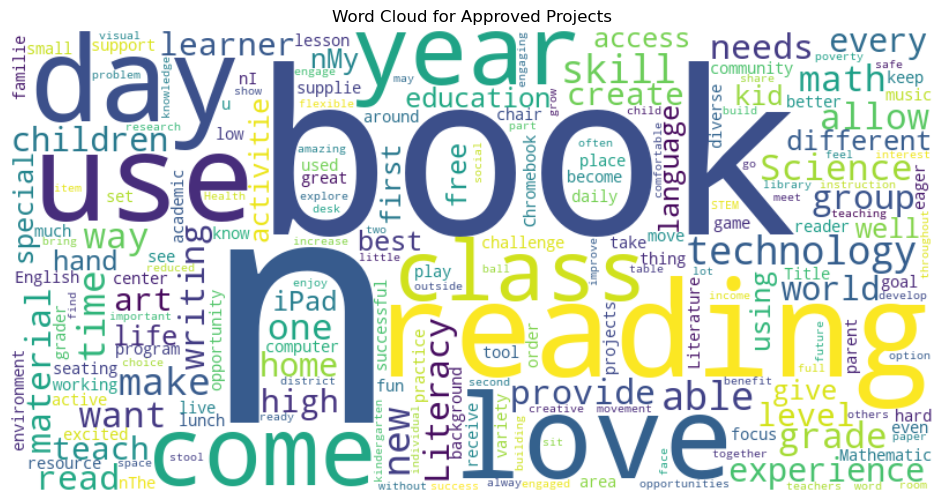

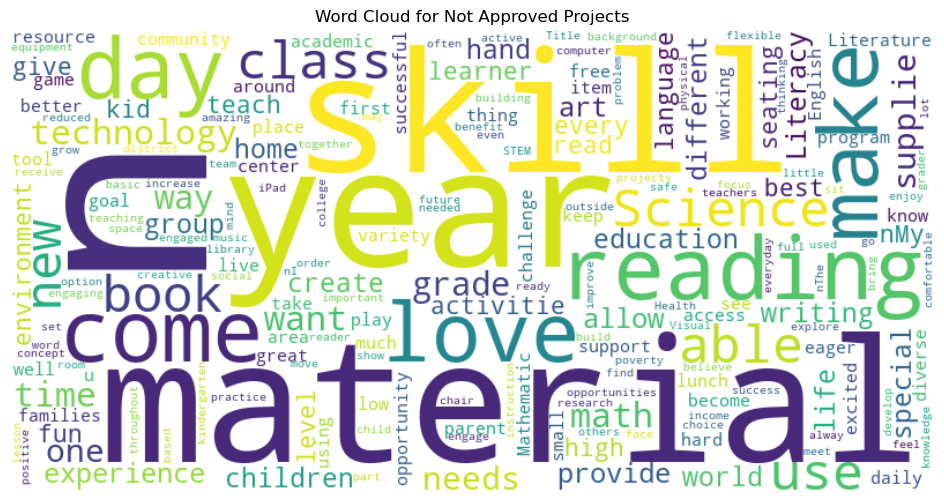

In [167]:
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    'student', 'students', 'teacher', 'school', 'project', 'need', 'classroom', 'help', 'learning', 'will', 'learn', 'many', 'work'
])

# Approved projects
wordcloud_approved = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    collocations=False
).generate(approved_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_approved, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Approved Projects")
plt.show()

# Not approved projects
wordcloud_not_approved = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    collocations=False
).generate(not_approved_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_not_approved, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Not Approved Projects")
plt.show()

#### Insights on the word cloud results

- There is no obvious seperation and difference between approved and rejected projects at a simple word-frequency level.
- The differences in words are not strong enough to rely on for predicition.
- Simple word frequency does not clearly distinguish approval outcomes.

In [168]:
df_clean = df_clean.drop(columns =[
    'project_title',
    'project_essay_1',
    'project_essay_2',
    'project_resource_summary',
    'project_subject_subcategories'
])

In [169]:
# Binning and Discretisation
# Group teacher experience into categories
df_clean['experience_bin'] = pd.cut(
    df_clean['teacher_number_of_previously_posted_projects'],
    bins=[0, 5, 10, 20, 50, 100, 200],
    labels=[0, 1, 2, 3, 4, 5]
)

In [177]:
df_clean['experience_bin'] = df_clean['experience_bin'].cat.add_categories([-1])
df_clean['experience_bin'] = df_clean['experience_bin'].fillna(-1)

In [178]:
df_clean['experience_bin'] = df_clean['experience_bin'].astype(int)

In [179]:
# Scale / normalise numerical features if required.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = [
    'teacher_number_of_previously_posted_projects',
    'submission_month',
    'submission_weekday'
]

df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [180]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 182076 entries, 0 to 182079
Data columns (total 19 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   teacher_prefix                                182076 non-null  float64
 1   school_state_0                                182076 non-null  int64  
 2   school_state_1                                182076 non-null  int64  
 3   school_state_2                                182076 non-null  int64  
 4   school_state_3                                182076 non-null  int64  
 5   school_state_4                                182076 non-null  int64  
 6   school_state_5                                182076 non-null  int64  
 7   project_grade_category                        182076 non-null  int64  
 8   project_subject_categories_0                  182076 non-null  int64  
 9   project_subject_categories_1                  182076 non-null  i

---
### Task 4: Integrate Data

If your project uses multiple data sources, this task involves merging or combining them into a single, unified dataset. Activities include:

- **Merging Tables:** Join datasets on common keys (e.g., using `pd.merge()`).
- **Appending Records:** Concatenate datasets with the same structure (e.g., using `pd.concat()`).
- **Aggregation:** Summarise data at a different level of granularity.

**Instructions:** If using multiple data sources, merge or concatenate them below. If your project uses a single dataset, document that here and proceed to the next task.

#### Objective
Combine multiple data sources into a single dataset where necessary.

#### Approach
Data integration is typically required when working with multiple datasets.
In this project, only a single dataset was used.

#### Actions Taken
- No additional datasets were merged.
- All transformations from previous steps were applied to a single dataset.

#### Reasoning
Since the project relies on one dataset, integration is not required.
However, this step confirms that the dataset is complete and ready for modelling.

#### Output
A final integrated dataset ('df_final) is made ready and prepared for modelling.

In [182]:
# Integrate data from multiple sources.

print("Single dataset used - no integration step required.", df_clean.shape)
df_final.head()

Single dataset used - no integration step required. (182076, 19)


,teacher_prefix,school_state_0,school_state_1,school_state_2,school_state_3,school_state_4,school_state_5,project_grade_category,project_subject_categories_0,project_subject_categories_1,project_subject_categories_2,project_subject_categories_3,project_subject_categories_4,project_subject_categories_5,teacher_number_of_previously_posted_projects,project_is_approved,experience_bin,submission_month,submission_weekday
0,0.357356,0,0,0,0,0,1,0,0,0,0,0,0,1,0.681202,1,3,1.259024,0.710655
1,0.523984,0,0,0,0,1,0,1,0,0,0,0,1,0,-0.421052,0,0,-0.862386,-0.358445
2,0.357356,0,0,0,0,1,1,1,0,0,0,0,1,1,-0.244692,1,0,-1.771562,1.779754
3,0.097031,0,0,0,1,0,0,1,0,0,0,1,0,0,0.240300,0,2,0.349848,0.710655
4,0.097031,0,0,0,1,0,1,2,0,0,0,1,0,0,1.386645,1,3,0.349848,1.245205


---
### Task 5: Format Data

This final preparation task ensures the data is in the correct format for the modelling tools. Activities include:

- **Data Type Conversions:** Ensure all columns have appropriate data types (e.g., numeric, datetime, categorical).
- **Column Reordering:** Arrange columns in a logical order (e.g., features first, target last).
- **Renaming:** Give columns clear, descriptive names.
- **Saving the Prepared Dataset:** Export the final, clean dataset for use in subsequent phases.

**Instructions:** Apply any final formatting changes and save the prepared dataset.

#### Objective
Ensure the dataset is fully prepared and suitable for modelling.

#### Approach
This task focuses on final formatting operations including:
- Checking and correcting data types
- Reordering columns
- Renaming columns where necessary.
- Exporting the final prepared dataset.

#### Actions Taken
- Verified and corrected data types where necessary.
- Ensure column names were all clear and consistent.
- Confirmed that the target variable appear last when reordering the columns.
- Save the final prepared dataset for use in the modelling phase.

#### Reasoning
Machine learning and training unsupervised models require clean, numerical, and consistent data.
Validating the dataset prevents errors during modelling and ensures reliable results.

#### Output
A validated dataset ready for modelling.

In [183]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 182076 entries, 0 to 182079
Data columns (total 19 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   teacher_prefix                                182076 non-null  float64
 1   school_state_0                                182076 non-null  int64  
 2   school_state_1                                182076 non-null  int64  
 3   school_state_2                                182076 non-null  int64  
 4   school_state_3                                182076 non-null  int64  
 5   school_state_4                                182076 non-null  int64  
 6   school_state_5                                182076 non-null  int64  
 7   project_grade_category                        182076 non-null  int64  
 8   project_subject_categories_0                  182076 non-null  int64  
 9   project_subject_categories_1                  182076 non-null  i

In [184]:
target = 'project_is_approved'
cols = [c for c in df_clean.columns if c != target] + [target]
df_clean = df_clean[cols]

In [185]:
df_clean.rename(columns={
    'teacher_number_of_previously_posted_projects' : 'teacher_experience',
}, inplace =True)

In [192]:
# Verify the final prepared dataset.

print("=" * 60)
print("             FINAL PREPARED DATASET SUMMARY")
print("=" * 60)

print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print("Dtypes:", df_clean.dtypes.value_counts())


print("\nData Types for every column:")
print(df_final.dtypes)
display(df_final.head())

             FINAL PREPARED DATASET SUMMARY
Shape: (182076, 19)
Missing values: 0
Dtypes: int64      15
float64     4
Name: count, dtype: int64

Data Types for every column:
teacher_prefix                                  float64
school_state_0                                    int64
school_state_1                                    int64
school_state_2                                    int64
school_state_3                                    int64
school_state_4                                    int64
school_state_5                                    int64
project_grade_category                            int64
project_subject_categories_0                      int64
project_subject_categories_1                      int64
project_subject_categories_2                      int64
project_subject_categories_3                      int64
project_subject_categories_4                      int64
project_subject_categories_5                      int64
teacher_number_of_previously_posted_projec

,teacher_prefix,school_state_0,school_state_1,school_state_2,school_state_3,school_state_4,school_state_5,project_grade_category,project_subject_categories_0,project_subject_categories_1,project_subject_categories_2,project_subject_categories_3,project_subject_categories_4,project_subject_categories_5,teacher_number_of_previously_posted_projects,project_is_approved,experience_bin,submission_month,submission_weekday
0,0.357356,0,0,0,0,0,1,0,0,0,0,0,0,1,0.681202,1,3,1.259024,0.710655
1,0.523984,0,0,0,0,1,0,1,0,0,0,0,1,0,-0.421052,0,0,-0.862386,-0.358445
2,0.357356,0,0,0,0,1,1,1,0,0,0,0,1,1,-0.244692,1,0,-1.771562,1.779754
3,0.097031,0,0,0,1,0,0,1,0,0,0,1,0,0,0.240300,0,2,0.349848,0.710655
4,0.097031,0,0,0,1,0,1,2,0,0,0,1,0,0,1.386645,1,3,0.349848,1.245205


In [193]:
# Save the prepared dataset for use in Phase 4 (Modelling).

OUTPUT_PATH = '../data/processed/prepared_data.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)
print(f"Prepared dataset saved to: {OUTPUT_PATH}")

Prepared dataset saved to: ../data/processed/prepared_data.csv


### Insights on the Data Preperation

The dataset was finalised to ensure compatibility with machine learning models. All features were converted to appropriate numeric data types, and any remaining categorical or missing values were resolved. Low - utility features were removed to reduce noise and simplify the model.

Columns were reordered so that input features appear first and the target variables (proejct_is_approved) is positioned last, improving clarity and consistency. Where appropriate, column names were refined for readability.

Finally, the fully prepared dataset was exported as a CSV file to enable reproducibility and efficient use in subsequent modeling phase.